<a href="https://colab.research.google.com/github/0702454835/HEADER-LOGO-AND-EDITED-SLIDER-IMAGES/blob/main/decision_tree_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
#Installing libraries
# graphviz is needed for visualizing the decision tree
!pip install graphviz

In [29]:
#importing libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz
import joblib # For saving and loading models
import os
import shutil # Added for robust directory removal

In [30]:
 #importing Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Convert to DataFrame for better inspection (optional)
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df['species'] = y

print("First 5 rows of Iris dataset:")
display(iris_df.head())
print(f"Dataset shape: {X.shape}")
print(f"Target classes: {iris.target_names}")


First 5 rows of Iris dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Dataset shape: (150, 4)
Target classes: ['setosa' 'versicolor' 'virginica']


In [31]:
# DATA CLEANING AND PREPARATION
# Check for missing values (Iris dataset is known to be clean)
print("Missing values per column:")
print(iris_df.isnull().sum())

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Shape of X_train: (105, 4)
Shape of X_test: (45, 4)
Shape of y_train: (105,)
Shape of y_test: (45,)


In [32]:
#DEVELOPING AND TRAINING DECISION TREE MODEL
# Initialize the Decision Tree Classifier
model = DecisionTreeClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully!")

Decision Tree Classifier trained successfully!


Accuracy: 0.93

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.80      0.89        15
   virginica       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45


Confusion Matrix:
[[15  0  0]
 [ 0 12  3]
 [ 0  0 15]]


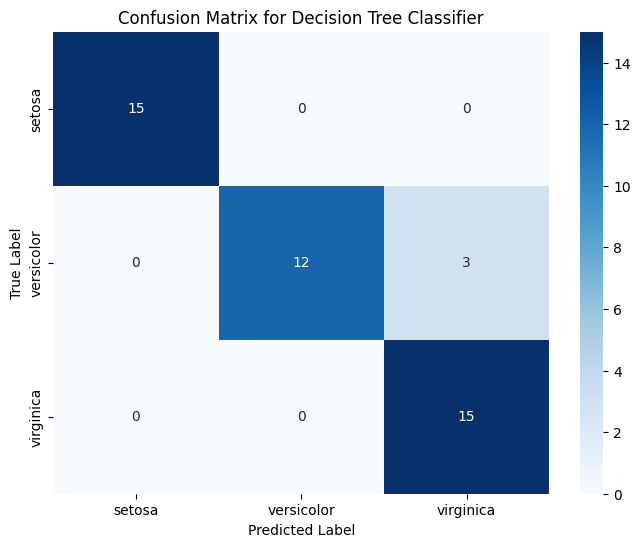

In [33]:
# TESTING AND EVALUATING THE MODEL
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.show()

Decision Tree visualization saved as iris_decision_tree.png


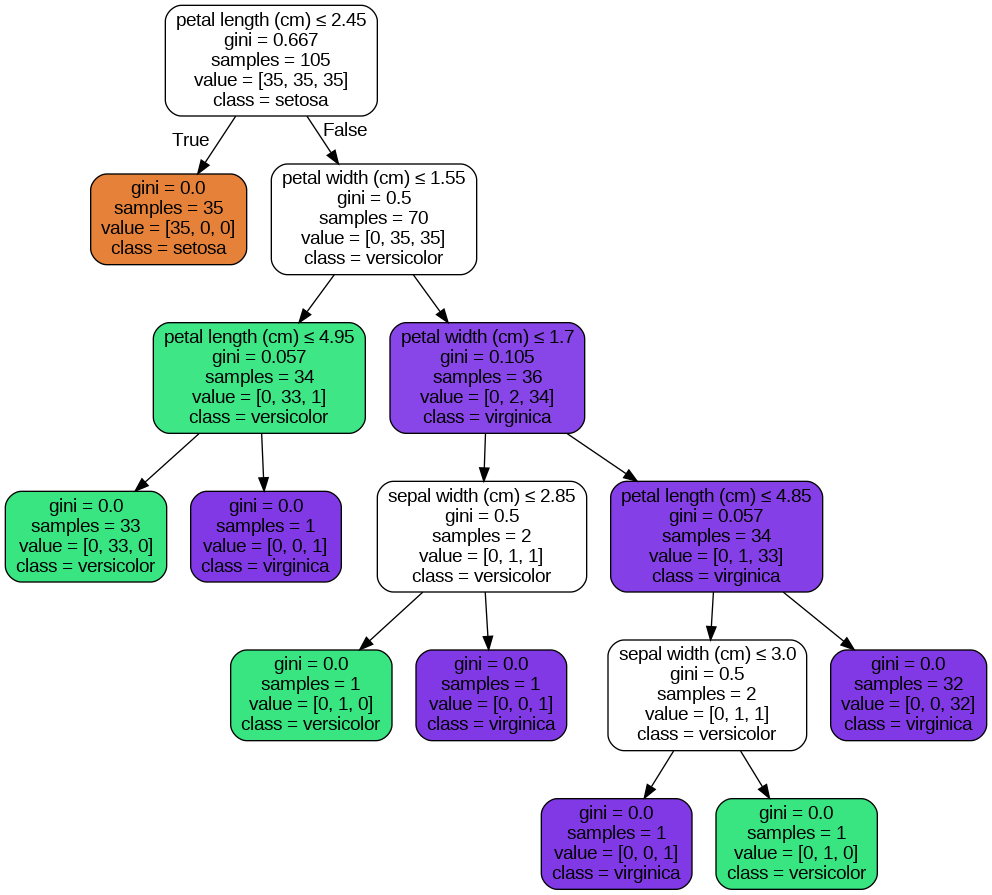

In [34]:
# VISUALIZATION OF THE DECISION TREE
# Export tree to a DOT file
dot_data = export_graphviz(model, out_file=None,
                         feature_names=iris.feature_names,
                         class_names=iris.target_names,
                         filled=True, rounded=True,
                         special_characters=True)

# Render the DOT graph
graph = graphviz.Source(dot_data)
graph.render("iris_decision_tree", view=False, format='png') # Saves as iris_decision_tree.png

print("Decision Tree visualization saved as iris_decision_tree.png")
# Display the tree  (requires graphviz to be installed and working)
from IPython.display import Image
Image(filename='iris_decision_tree.png')

In [ ]:
#